# Step Failure Modeling

This notebook was split from the original G'Contest final-round working notebook for faster GitHub review. Raw data and data-loading code are intentionally excluded. Saved outputs are preserved so interviewers can inspect the completed analysis and results without rerunning the private dataset.

**Interview focus:** Models specific failure points such as OTP, OCR, selfie, contract, and final-check failures to support diagnostic insights.


# **VI. Modeling - Dự đoán khách hàng bị fail ở từng bước**

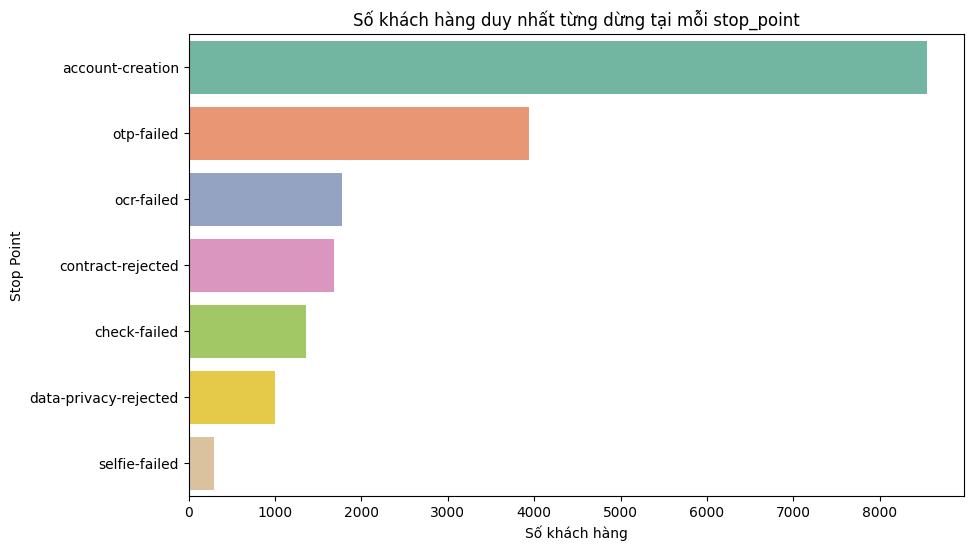

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fail_per_step = (
    df.groupby('stop_point')['customer_id']
    .nunique()
    .reset_index(name='n_customers')
    .sort_values('n_customers', ascending=False)
)

# Vẽ biểu đồ đúng insight
plt.figure(figsize=(10,6))
sns.barplot(data=fail_per_step, x='n_customers', y='stop_point', palette='Set2')
plt.title('Số khách hàng duy nhất từng dừng tại mỗi stop_point')
plt.xlabel('Số khách hàng')
plt.ylabel('Stop Point')
plt.show()


In [ ]:
df_model_combine.columns

Index(['customer_id', 'age', 'status', 'hour_of_day', 'day_of_week',
       'cumulative_attempts', 'stop_point_mapped', 'total_fail_past',
       'total_pending_past', 'is_office_hour', 'is_weekend',
       'fail_pending_count_otp-failed',
       'fail_pending_count_data-privacy-rejected',
       'fail_pending_count_ocr-failed', 'fail_pending_count_selfie-failed',
       'fail_pending_count_contract-rejected',
       'fail_pending_count_check-failed', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening',
       'time_morning'],
      dtype='object')

In [ ]:
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'status', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X_step, y_step, df_user_step = build_user_level_step_dataset(df_model_combine, step=0)

y_step.value_counts()

,count
fail_step_0,
0,5203
1,3945


## OTP Failure

### LightGBM

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 5203, number of negative: 5203
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001670 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 10406, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

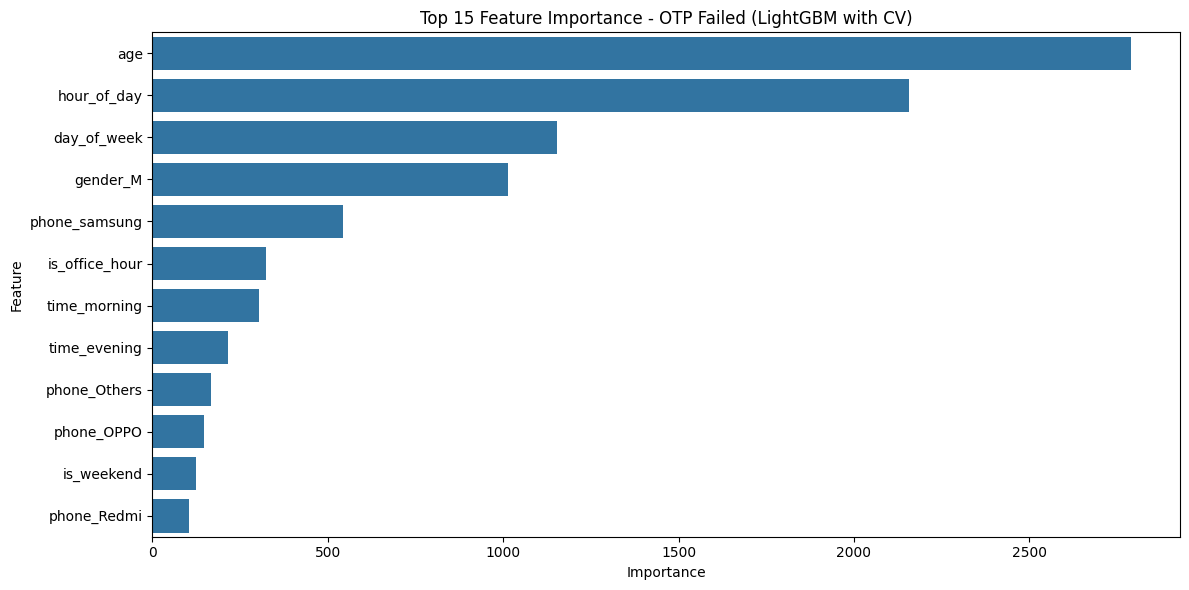

[LightGBM] [Info] Number of positive: 4162, number of negative: 4162
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001233 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 343
[LightGBM] [Info] Number of data points in the train set: 8324, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score



# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=0)

# 2. SMOTE + LightGBM pipeline
lgb = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgb', lgb)
])

# 3. Hyperparameter space
param_dist = {
    'lgb__n_estimators': [100, 200, 300],
    'lgb__max_depth': [3, 5, 7, -1],
    'lgb__learning_rate': [0.01, 0.05, 0.1],
    'lgb__num_leaves': [15, 31, 50],
    'lgb__subsample': [0.6, 0.8, 1.0],
    'lgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Feature importance từ final model
final_model = best_model.named_steps['lgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - OTP Failed (LightGBM with CV)")
plt.tight_layout()
plt.show()

# 7. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=best_model,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - OTP Fail (LightGBM):")
print(cv_summary)


### Random Forest

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'rf__n_estimators': 300, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': 10}
📈 CV score mean (ROC AUC): 0.6343


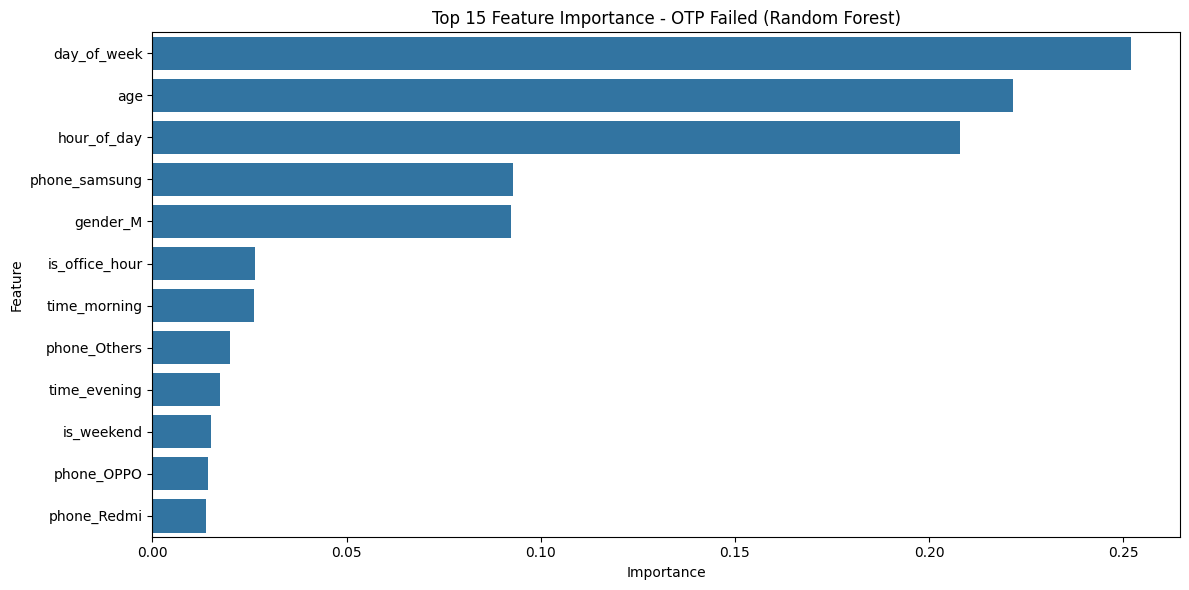


📊 Đánh giá mô hình - OTP Fail (Random Forest):
      Metric  Mean Score
0    ROC AUC    0.634348
1   Accuracy    0.608329
2   F1 Score    0.532912
3  Precision    0.549216
4     Recall    0.518378


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report, roc_auc_score, make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=0)

# 2. SMOTE + RandomForest Pipeline
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', rf)
])

# 3. Hyperparameter space
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['rf']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - OTP Failed (Random Forest)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - OTP Fail (Random Forest):")
print(cv_summary)


### XGBoost

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'xgb__subsample': 0.6, 'xgb__n_estimators': 300, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 0.6}
📈 CV score mean: 0.6346


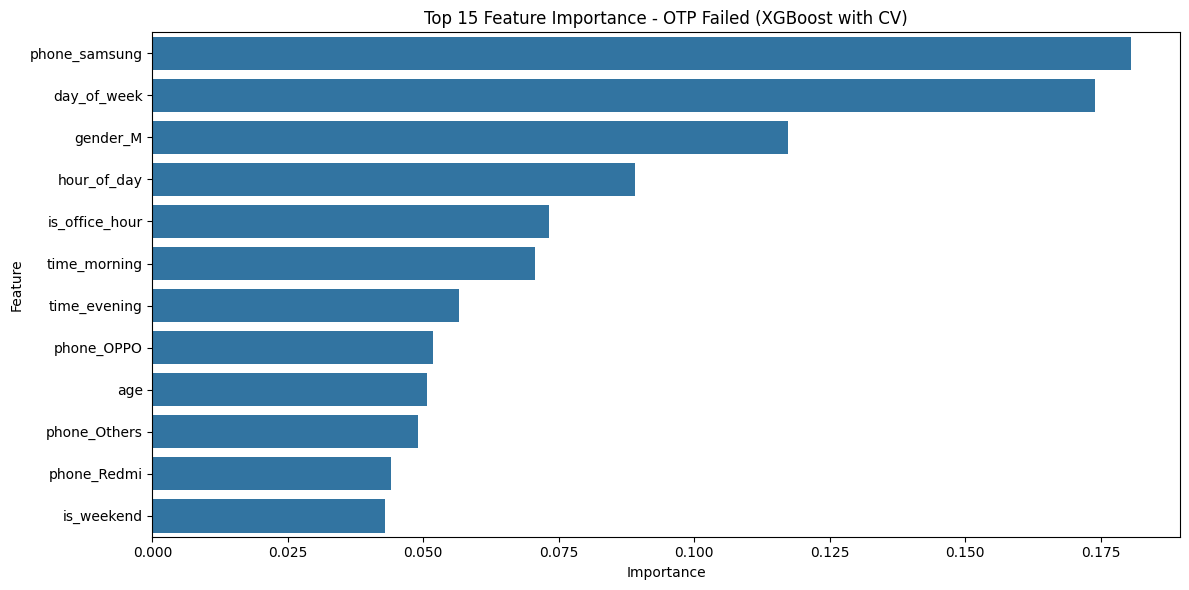


📊 Đánh giá mô hình - OTP Fail:
      Metric  Mean Score
0    ROC AUC    0.634613
1   Accuracy    0.606361
2   F1 Score    0.534455
3  Precision    0.545856
4     Recall    0.524208


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=0)

# 2. SMOTE + XGBoost Pipeline
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

# 3. Hyperparameter space
param_dist = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['xgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - OTP Failed (XGBoost with CV)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - OTP Fail:")
print(cv_summary)


## Data Privacy Rejection

### LightGBM

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 8032, number of negative: 8032
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001865 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1198
[LightGBM] [Info] Number of data points in the train set: 16064, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

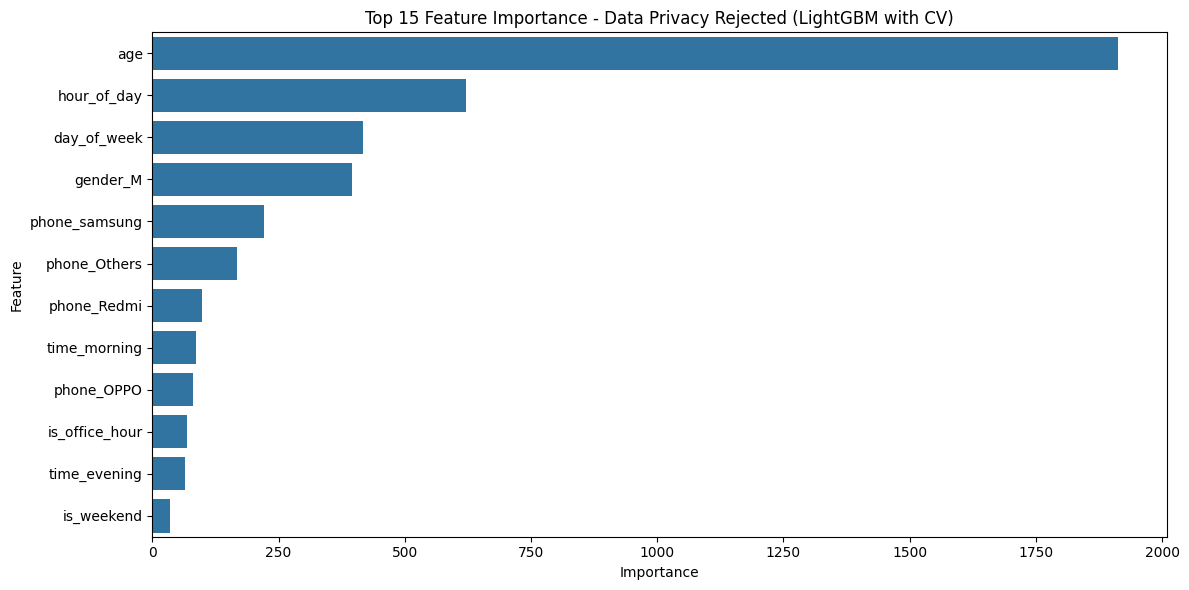

[LightGBM] [Info] Number of positive: 6425, number of negative: 6425
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001615 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1040
[LightGBM] [Info] Number of data points in the train set: 12850, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=1)

# 2. SMOTE + LightGBM pipeline
lgb = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgb', lgb)
])

# 3. Hyperparameter space
param_dist = {
    'lgb__n_estimators': [100, 200, 300],
    'lgb__max_depth': [3, 5, 7, -1],
    'lgb__learning_rate': [0.01, 0.05, 0.1],
    'lgb__num_leaves': [15, 31, 50],
    'lgb__subsample': [0.6, 0.8, 1.0],
    'lgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Feature importance từ final model
final_model = best_model.named_steps['lgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Data Privacy Rejected (LightGBM with CV)")
plt.tight_layout()
plt.show()

# 7. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=best_model,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Data Privacy Rejected (LightGBM):")
print(cv_summary)


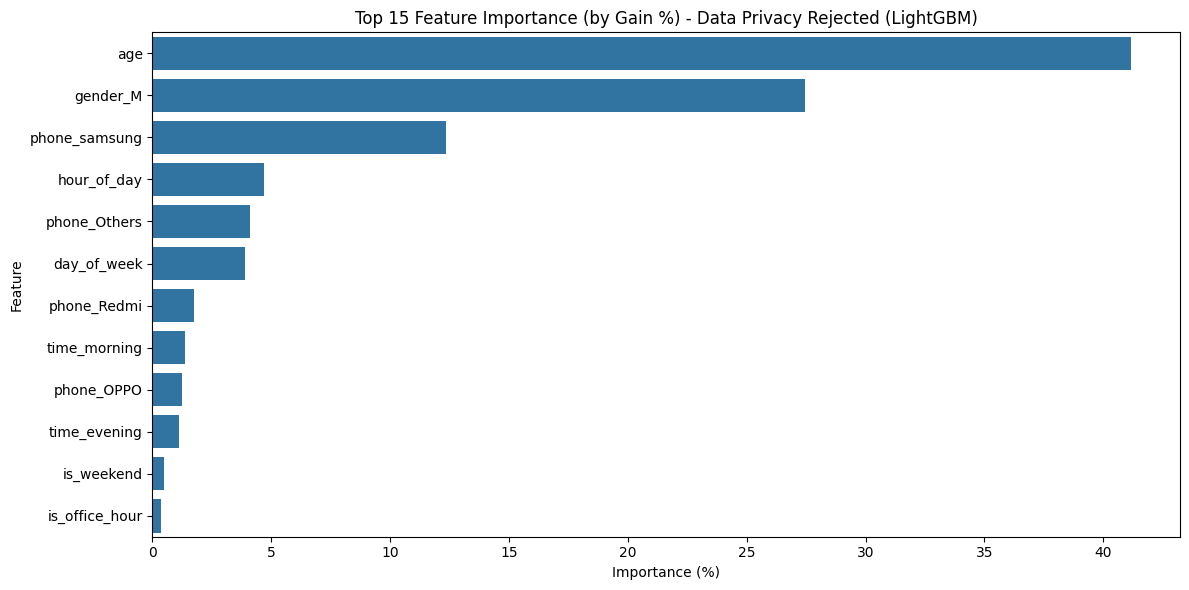

🔍 Top features (by % gain):
           Feature  Importance (%)
0              age       41.166075
5         gender_M       27.466277
9    phone_samsung       12.352066
1      hour_of_day        4.703201
7     phone_Others        4.102419
2      day_of_week        3.900906
8      phone_Redmi        1.746398
11    time_morning        1.354172
6       phone_OPPO        1.242720
10    time_evening        1.112576
4       is_weekend        0.508748
3   is_office_hour        0.344443


In [ ]:
# 6. Feature importance theo gain, chuẩn hóa theo tỷ lệ %

# Lấy booster của LightGBM từ pipeline
booster = final_model.booster_

# Lấy importance theo 'gain' (tổng độ giảm loss do mỗi feature đóng góp)
gain_importance = booster.feature_importance(importance_type='gain')
gain_importance_pct = gain_importance / gain_importance.sum() * 100  # chuyển về tỷ lệ %

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance (%)': gain_importance_pct
}).sort_values(by='Importance (%)', ascending=False)

# Vẽ biểu đồ top 15
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance (%)', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance (by Gain %) - Data Privacy Rejected (LightGBM)")
plt.tight_layout()
plt.show()

# In top features
print("🔍 Top features (by % gain):")
print(importance_df.head(15))


### Random Forest

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'rf__n_estimators': 200, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 4, 'rf__max_features': 'sqrt', 'rf__max_depth': None}
📈 CV score mean (ROC AUC): 0.6017


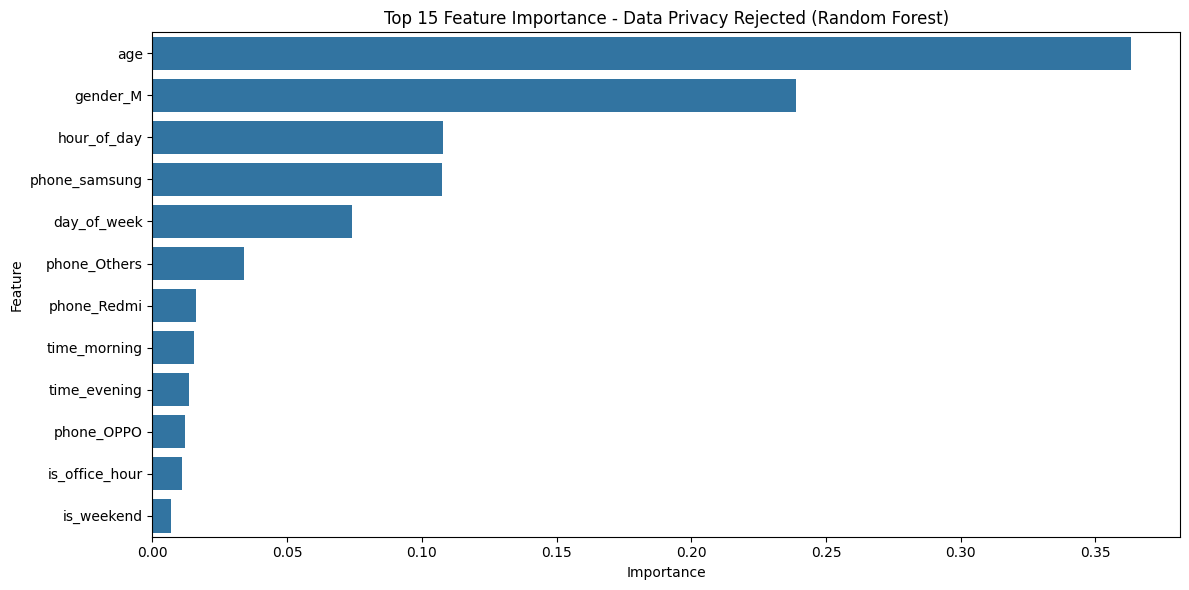


📊 Đánh giá mô hình - Data Privacy Rejected (Random Forest):
      Metric  Mean Score
0    ROC AUC    0.601708
1   Accuracy    0.817658
2   F1 Score    0.228033
3  Precision    0.214430
4     Recall    0.244221


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report, roc_auc_score, make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=1)

# 2. SMOTE + RandomForest Pipeline
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', rf)
])

# 3. Hyperparameter space
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['rf']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Data Privacy Rejected (Random Forest)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Data Privacy Rejected (Random Forest):")
print(cv_summary)


### XGBoost

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'xgb__subsample': 0.6, 'xgb__n_estimators': 300, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.1, 'xgb__colsample_bytree': 0.8}
📈 CV score mean: 0.6020


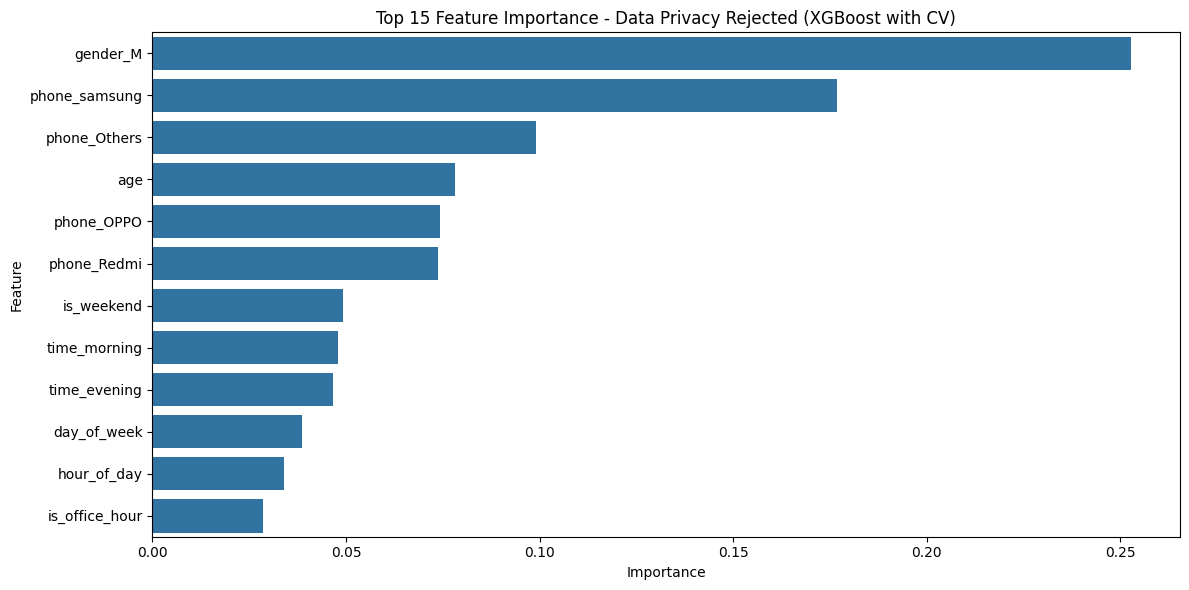


📊 Đánh giá mô hình - Data Privacy Rejected:
      Metric  Mean Score
0    ROC AUC    0.602013
1   Accuracy    0.833608
2   F1 Score    0.248869
3  Precision    0.250178
4     Recall    0.249246


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=1)

# 2. SMOTE + XGBoost Pipeline
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

# 3. Hyperparameter space
param_dist = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['xgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Data Privacy Rejected (XGBoost with CV)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Data Privacy Rejected:")
print(cv_summary)


## OCR Failure

### LightGBM

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 7085, number of negative: 7085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1000
[LightGBM] [Info] Number of data points in the train set: 14170, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ Best hyperparameters:
{'lgb__subsample': 0.6, 'lgb__num_leaves': 15, 'lgb__n_estimators': 300, 'lgb__max_depth': 7, 'lgb__learning_rate': 0.01, 'lgb__colsample_bytree': 1.0}
📈 CV score mean (ROC AUC): 0.5786
[LightGBM] [Info] Number of positive: 7085, number of negative: 7085
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002989 seconds.
You can set `force_row_wise=true` to remove the overhe

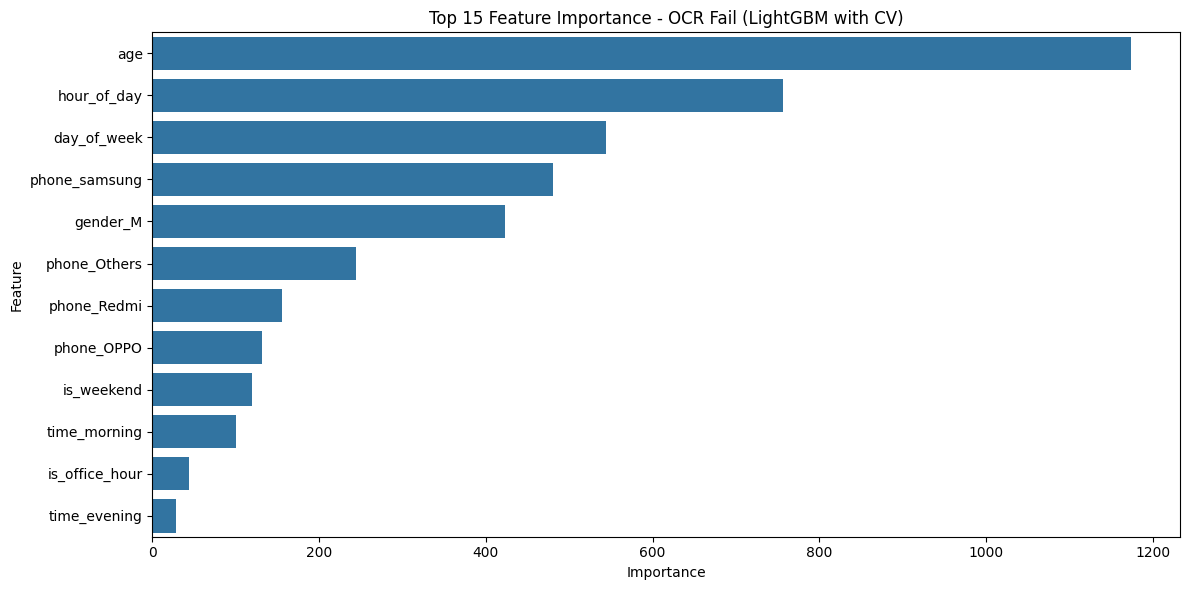

[LightGBM] [Info] Number of positive: 5668, number of negative: 5668
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001855 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 965
[LightGBM] [Info] Number of data points in the train set: 11336, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 5668, number of negative: 5668
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001300 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 950
[LightGBM] [Info] Number of data points in the train set: 11336, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 5668, number of negative: 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=2)

# 2. SMOTE + LightGBM pipeline
lgb = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgb', lgb)
])

# 3. Hyperparameter space
param_dist = {
    'lgb__n_estimators': [100, 200, 300],
    'lgb__max_depth': [3, 5, 7, -1],
    'lgb__learning_rate': [0.01, 0.05, 0.1],
    'lgb__num_leaves': [15, 31, 50],
    'lgb__subsample': [0.6, 0.8, 1.0],
    'lgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Feature importance từ final model
final_model = best_model.named_steps['lgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - OCR Fail (LightGBM with CV)")
plt.tight_layout()
plt.show()

# 7. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=best_model,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - OCR Fail (LightGBM):")
print(cv_summary)


### Random Forest

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'rf__n_estimators': 200, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': None, 'rf__max_depth': 10}
📈 CV score mean (ROC AUC): 0.5802


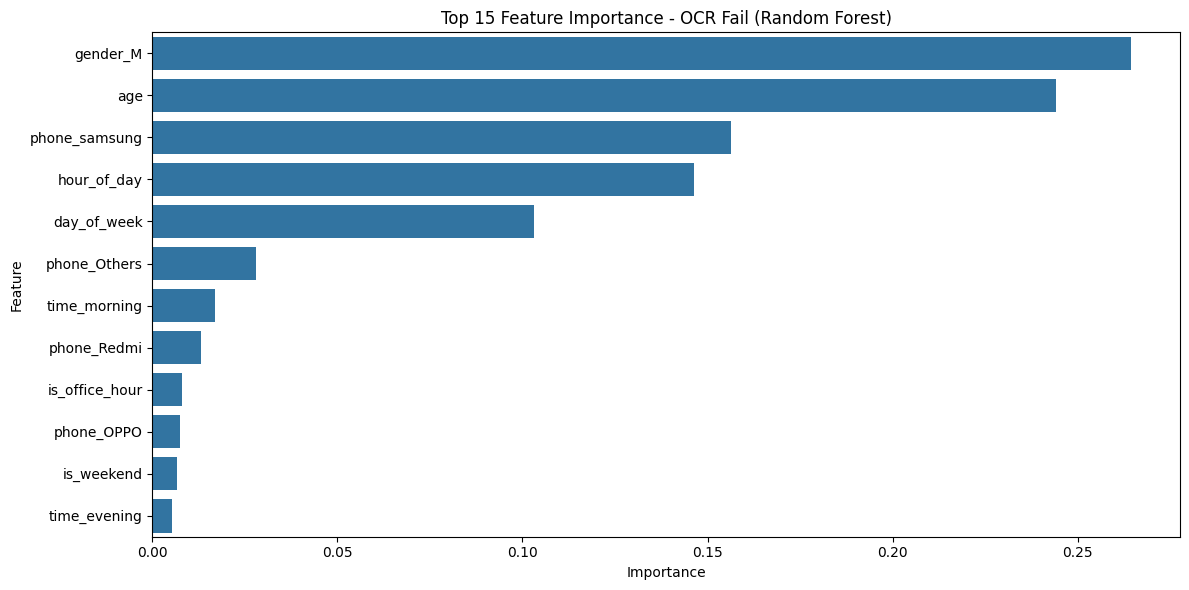


📊 Đánh giá mô hình - OCR Fail (Random Forest):
      Metric  Mean Score
0    ROC AUC    0.580197
1   Accuracy    0.728967
2   F1 Score    0.279425
3  Precision    0.300035
4     Recall    0.263277


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report, roc_auc_score, make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=2)

# 2. SMOTE + RandomForest Pipeline
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', rf)
])

# 3. Hyperparameter space
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['rf']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - OCR Fail (Random Forest)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - OCR Fail (Random Forest):")
print(cv_summary)


### XGBoost

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'xgb__subsample': 1.0, 'xgb__n_estimators': 300, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 1.0}
📈 CV score mean: 0.5783


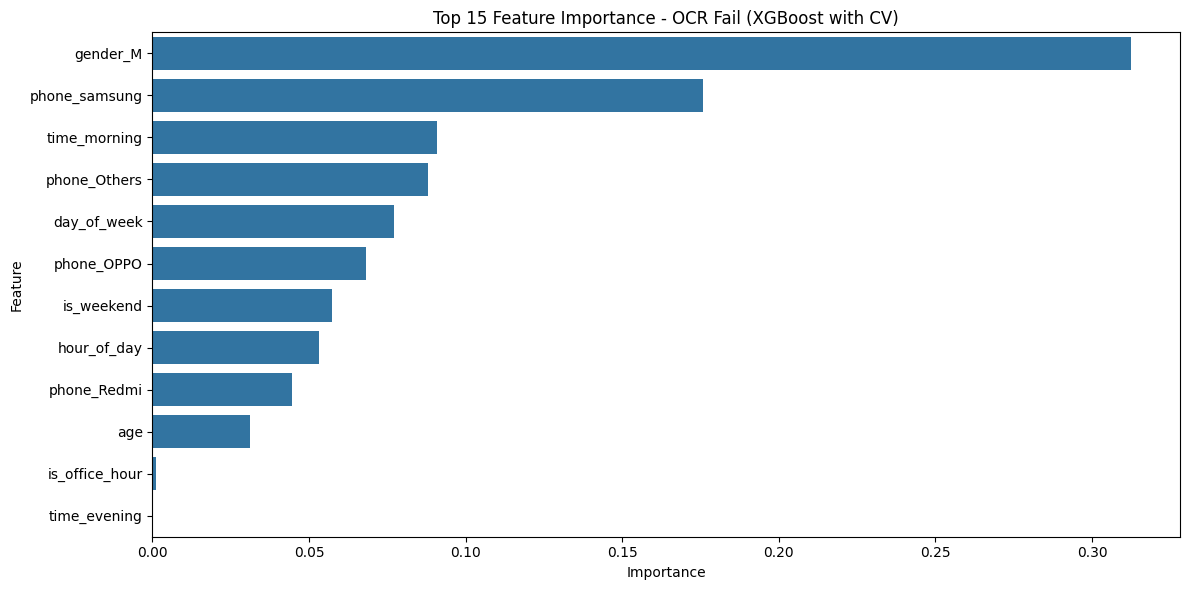


📊 Đánh giá mô hình - OCR Fail:
      Metric  Mean Score
0    ROC AUC    0.578319
1   Accuracy    0.715415
2   F1 Score    0.289045
3  Precision    0.290325
4     Recall    0.289266


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns
# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=2)

# 2. SMOTE + XGBoost Pipeline
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

# 3. Hyperparameter space
param_dist = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['xgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - OCR Fail (XGBoost with CV)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - OCR Fail:")
print(cv_summary)


## Selfie Failure

### LightGBM

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 8325, number of negative: 8325
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001893 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1545
[LightGBM] [Info] Number of data points in the train set: 16650, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ Best hyperparameters:
{'lgb__subsample': 0.6, 'lgb__num_leaves': 15, 'lgb__n_estimators': 300, 'lgb__max_depth': 7, 'lgb__learning_rate': 0.01, 'lgb__colsample_bytree': 1.0}
📈 CV score mean (ROC AUC): 0.5536
[LightGBM] [Info] Number of positive: 8325, number of negative: 8325
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002093 seconds.
You can set `force_row_wise=true` to remove the overhe

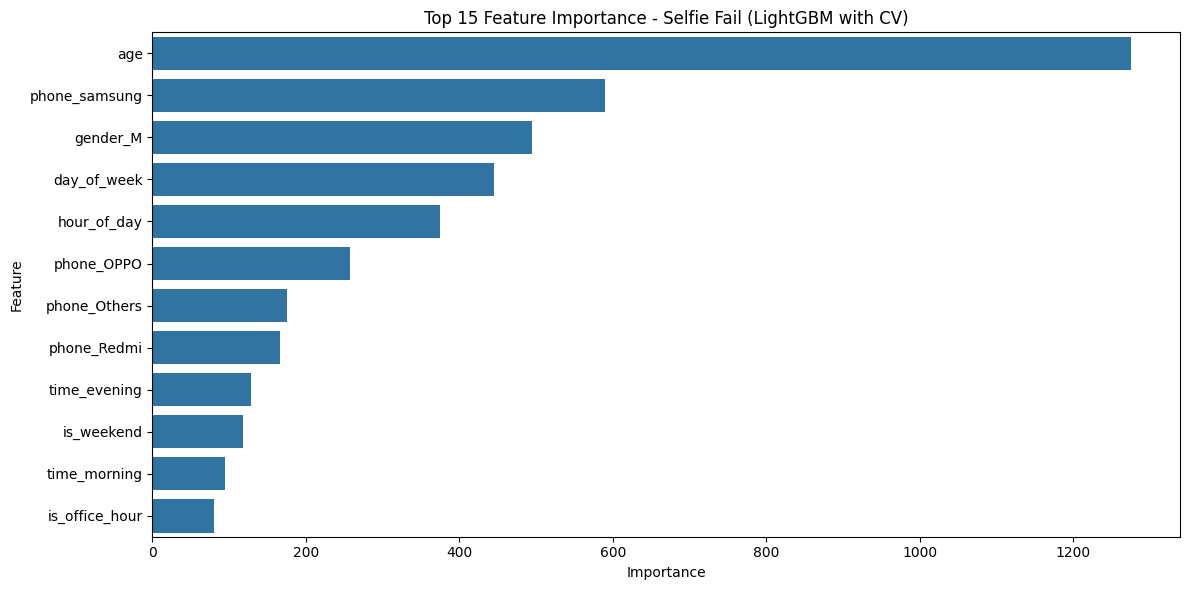

[LightGBM] [Info] Number of positive: 6660, number of negative: 6660
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1470
[LightGBM] [Info] Number of data points in the train set: 13320, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 6660, number of negative: 6660
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001489 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1179
[LightGBM] [Info] Number of data points in the train set: 13320, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.00000

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=3)

# 2. SMOTE + LightGBM pipeline
lgb = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgb', lgb)
])

# 3. Hyperparameter space
param_dist = {
    'lgb__n_estimators': [100, 200, 300],
    'lgb__max_depth': [3, 5, 7, -1],
    'lgb__learning_rate': [0.01, 0.05, 0.1],
    'lgb__num_leaves': [15, 31, 50],
    'lgb__subsample': [0.6, 0.8, 1.0],
    'lgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Feature importance từ final model
final_model = best_model.named_steps['lgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Selfie Fail (LightGBM with CV)")
plt.tight_layout()
plt.show()

# 7. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=best_model,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Selfie Fail (LightGBM):")
print(cv_summary)


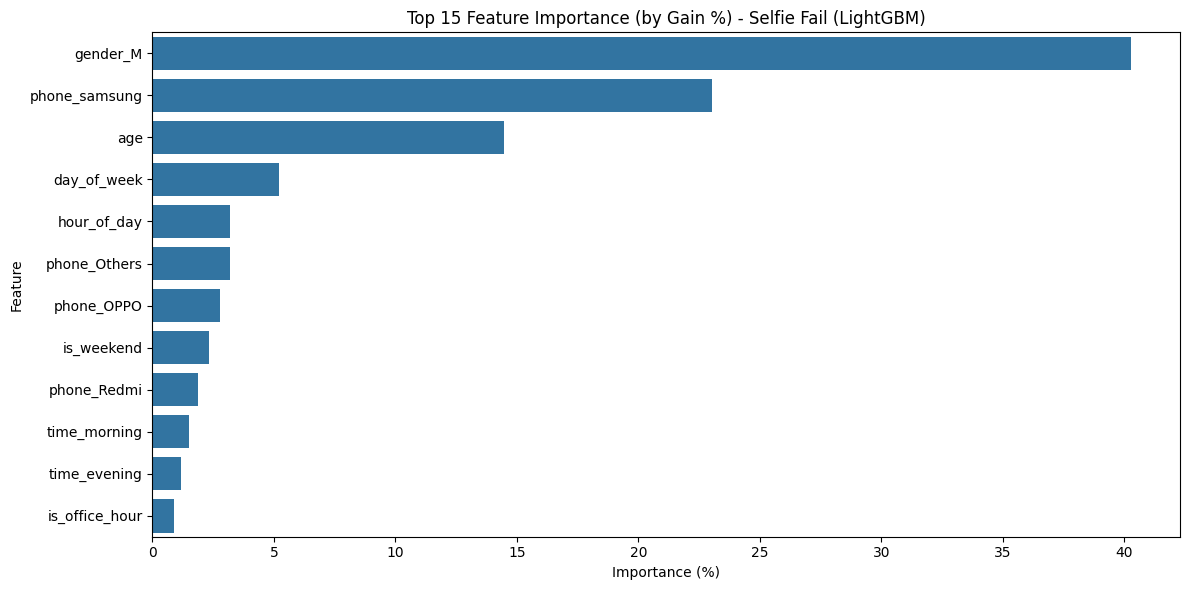

🔍 Top features (by % gain):
           Feature  Importance (%)
5         gender_M       40.279128
9    phone_samsung       23.047219
0              age       14.466925
2      day_of_week        5.227837
1      hour_of_day        3.198949
7     phone_Others        3.184056
6       phone_OPPO        2.798611
4       is_weekend        2.333221
8      phone_Redmi        1.896300
11    time_morning        1.517708
10    time_evening        1.172350
3   is_office_hour        0.877696


In [ ]:
# 6. Feature importance theo gain, chuẩn hóa theo tỷ lệ %

# Lấy booster của LightGBM từ pipeline
booster = final_model.booster_

# Lấy importance theo 'gain' (tổng độ giảm loss do mỗi feature đóng góp)
gain_importance = booster.feature_importance(importance_type='gain')
gain_importance_pct = gain_importance / gain_importance.sum() * 100  # chuyển về tỷ lệ %

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance (%)': gain_importance_pct
}).sort_values(by='Importance (%)', ascending=False)

# Vẽ biểu đồ top 15
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance (%)', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance (by Gain %) - Selfie Fail (LightGBM)")
plt.tight_layout()
plt.show()

# In top features
print("🔍 Top features (by % gain):")
print(importance_df.head(15))


### Random Forest

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'rf__n_estimators': 100, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': 'sqrt', 'rf__max_depth': None}
📈 CV score mean (ROC AUC): 0.5694


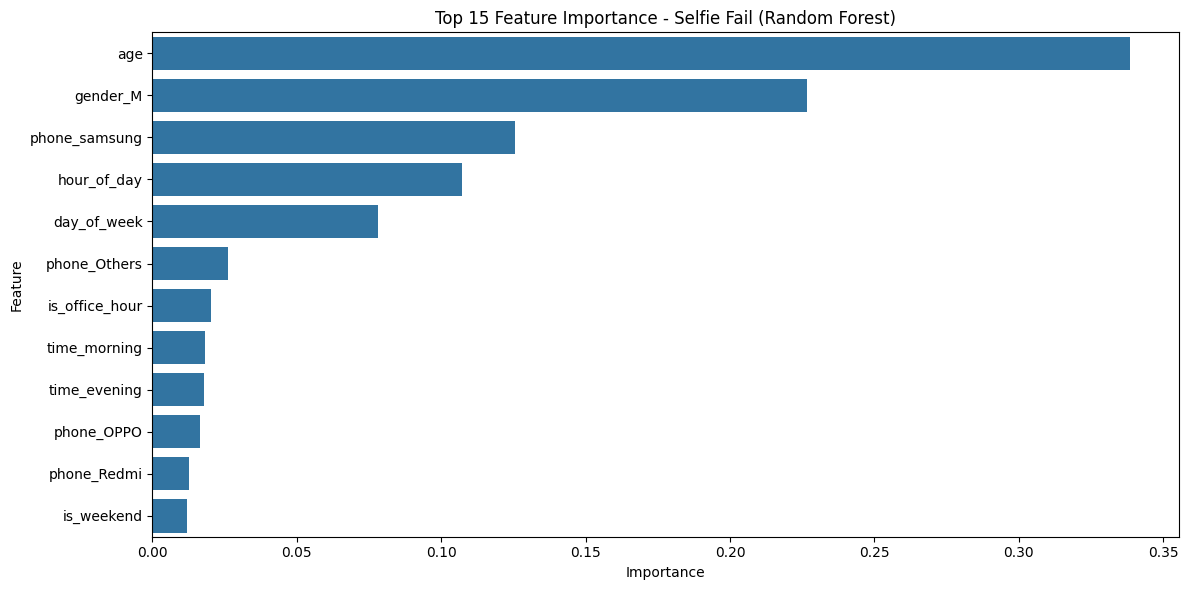


📊 Đánh giá mô hình - Selfie Fail (Random Forest):
      Metric  Mean Score
0    ROC AUC    0.569413
1   Accuracy    0.912095
2   F1 Score    0.035901
3  Precision    0.029115
4     Recall    0.046949


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report, roc_auc_score, make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=3)




# 2. SMOTE + RandomForest Pipeline
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', rf)
])

# 3. Hyperparameter space
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['rf']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Selfie Fail (Random Forest)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Selfie Fail (Random Forest):")
print(cv_summary)


### XGBoost

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'xgb__subsample': 1.0, 'xgb__n_estimators': 200, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.8}
📈 CV score mean: 0.5490


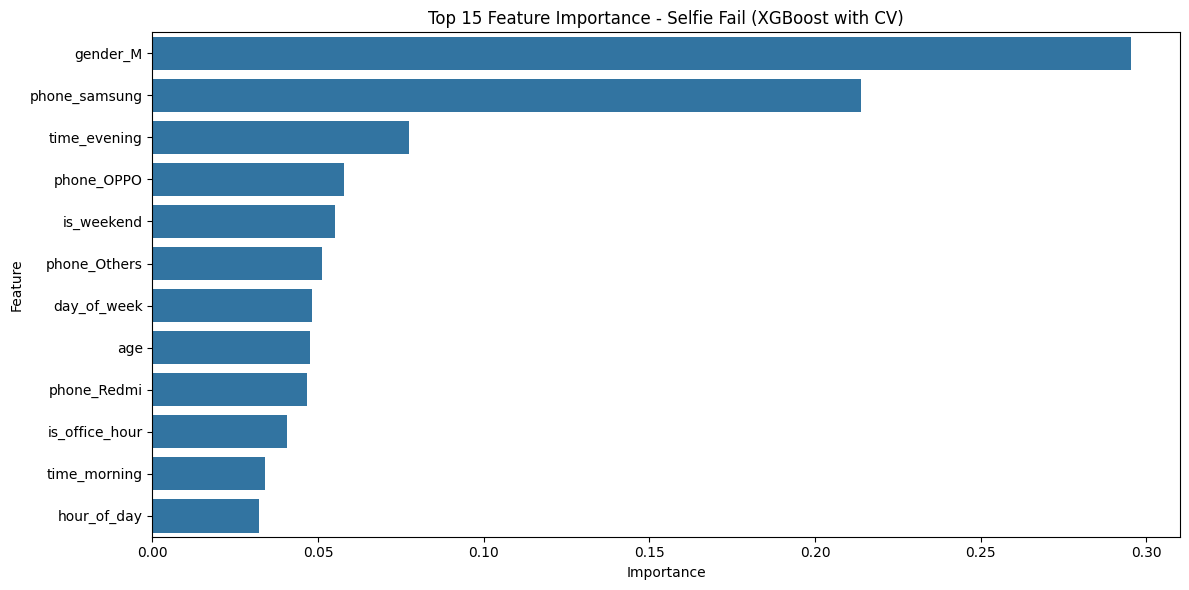


📊 Đánh giá mô hình - Selfie Fail:
      Metric  Mean Score
0    ROC AUC    0.548978
1   Accuracy    0.920330
2   F1 Score    0.079366
3  Precision    0.067549
4     Recall    0.097288


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=3)


# 2. SMOTE + XGBoost Pipeline
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

# 3. Hyperparameter space
param_dist = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['xgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Selfie Fail (XGBoost with CV)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Selfie Fail:")
print(cv_summary)


## Contract Rejection

### LightGBM

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 6933, number of negative: 6933
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001581 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 978
[LightGBM] [Info] Number of data points in the train set: 13866, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
✅ Best hyperparameters:
{'lgb__subsample': 0.6, 'lgb__num_leaves': 31, 'lgb__n_estimators': 200, 'lgb__max_depth': 7, 'lgb__learning_rate': 0.01, 'lgb__colsample_bytree': 1.0}
📈 CV score mean (ROC AUC): 0.6821
[LightGBM] [Info] Number of positive: 6933, number of negative: 6933
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001608 seconds.
You can set `force_row_wise=true` to remove the overhea

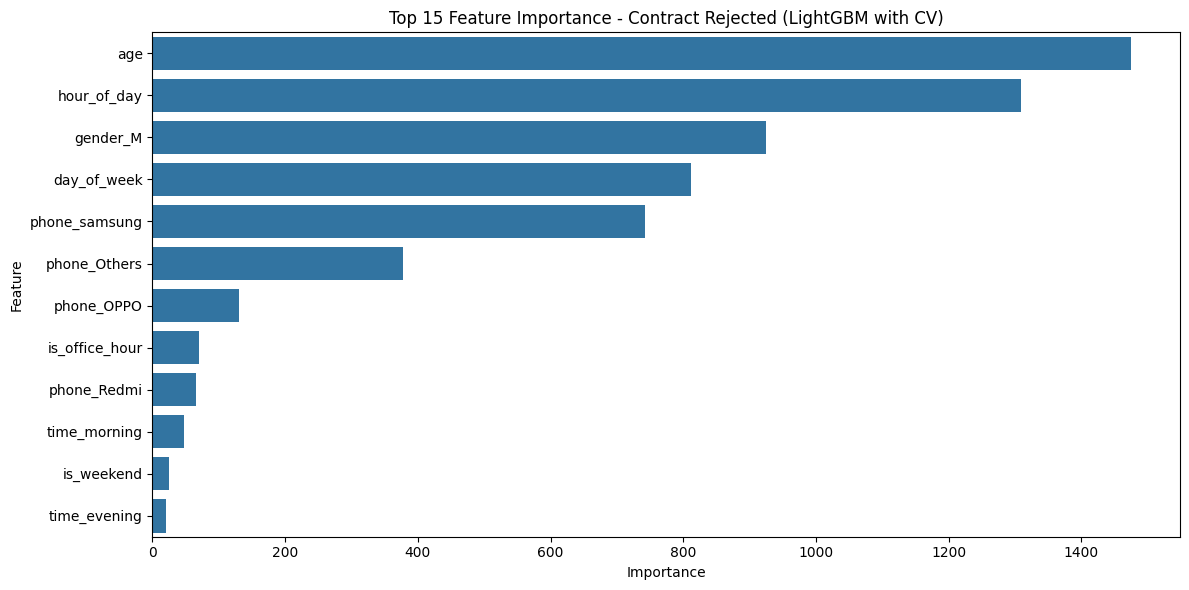

[LightGBM] [Info] Number of positive: 5546, number of negative: 5546
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001386 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 961
[LightGBM] [Info] Number of data points in the train set: 11092, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Number of positive: 5546, number of negative: 5546
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001283 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 936
[LightGBM] [Info] Number of data points in the train set: 11092, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=4)

# 2. SMOTE + LightGBM pipeline
lgb = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgb', lgb)
])

# 3. Hyperparameter space
param_dist = {
    'lgb__n_estimators': [100, 200, 300],
    'lgb__max_depth': [3, 5, 7, -1],
    'lgb__learning_rate': [0.01, 0.05, 0.1],
    'lgb__num_leaves': [15, 31, 50],
    'lgb__subsample': [0.6, 0.8, 1.0],
    'lgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Feature importance từ final model
final_model = best_model.named_steps['lgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Contract Rejected (LightGBM with CV)")
plt.tight_layout()
plt.show()

# 7. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=best_model,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Contract Rejected (LightGBM):")
print(cv_summary)


### Random Forest

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'rf__n_estimators': 100, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 2, 'rf__max_features': None, 'rf__max_depth': 5}
📈 CV score mean (ROC AUC): 0.6819


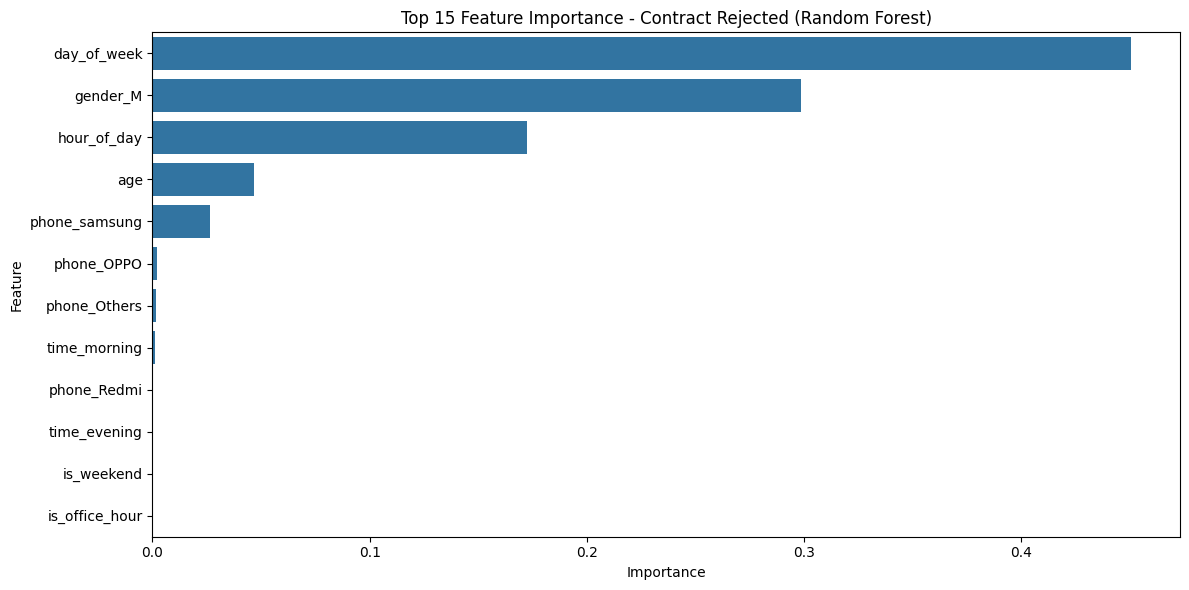


📊 Đánh giá mô hình - Contract Rejected (Random Forest):
      Metric  Mean Score
0    ROC AUC    0.681880
1   Accuracy    0.686979
2   F1 Score    0.418395
3  Precision    0.328543
4     Recall    0.576915


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report, roc_auc_score, make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=4)

# 2. SMOTE + RandomForest Pipeline
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', rf)
])

# 3. Hyperparameter space
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['rf']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Contract Rejected (Random Forest)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Contract Rejected (Random Forest):")
print(cv_summary)


### XGBoost

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'xgb__subsample': 0.8, 'xgb__n_estimators': 200, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 1.0}
📈 CV score mean: 0.6806


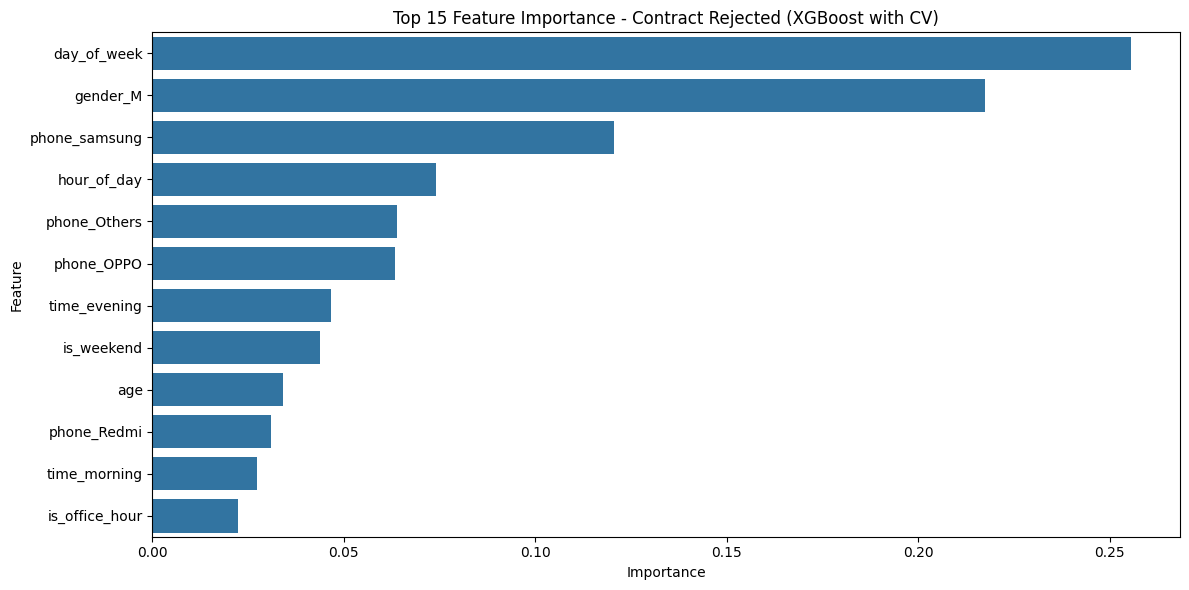


📊 Đánh giá mô hình - Contract Rejected:
      Metric  Mean Score
0    ROC AUC    0.680642
1   Accuracy    0.718781
2   F1 Score    0.415987
3  Precision    0.350208
4     Recall    0.512760


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=4)

# 2. SMOTE + XGBoost Pipeline
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

# 3. Hyperparameter space
param_dist = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['xgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Contract Rejected (XGBoost with CV)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Contract Rejected:")
print(cv_summary)


## Final Check Failure

### LightGBM

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Info] Number of positive: 7216, number of negative: 7216
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002240 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1003
[LightGBM] [Info] Number of data points in the train set: 14432, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

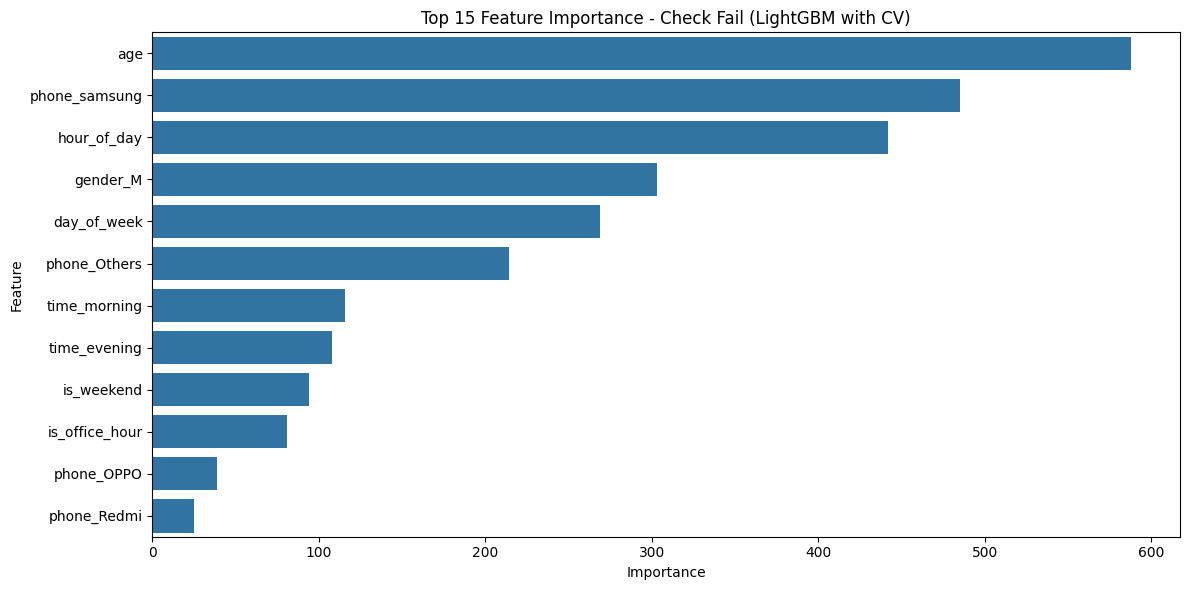

[LightGBM] [Info] Number of positive: 5772, number of negative: 5772
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001866 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 992
[LightGBM] [Info] Number of data points in the train set: 11544, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=5)

# 2. SMOTE + LightGBM pipeline
lgb = LGBMClassifier(
    objective='binary',
    random_state=42,
    n_jobs=-1
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgb', lgb)
])

# 3. Hyperparameter space
param_dist = {
    'lgb__n_estimators': [100, 200, 300],
    'lgb__max_depth': [3, 5, 7, -1],
    'lgb__learning_rate': [0.01, 0.05, 0.1],
    'lgb__num_leaves': [15, 31, 50],
    'lgb__subsample': [0.6, 0.8, 1.0],
    'lgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Feature importance từ final model
final_model = best_model.named_steps['lgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Check Fail (LightGBM with CV)")
plt.tight_layout()
plt.show()

# 7. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=best_model,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Check Fail (LightGBM):")
print(cv_summary)


### Random Forest

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'rf__n_estimators': 300, 'rf__min_samples_split': 2, 'rf__min_samples_leaf': 1, 'rf__max_features': None, 'rf__max_depth': 5}
📈 CV score mean (ROC AUC): 0.5985


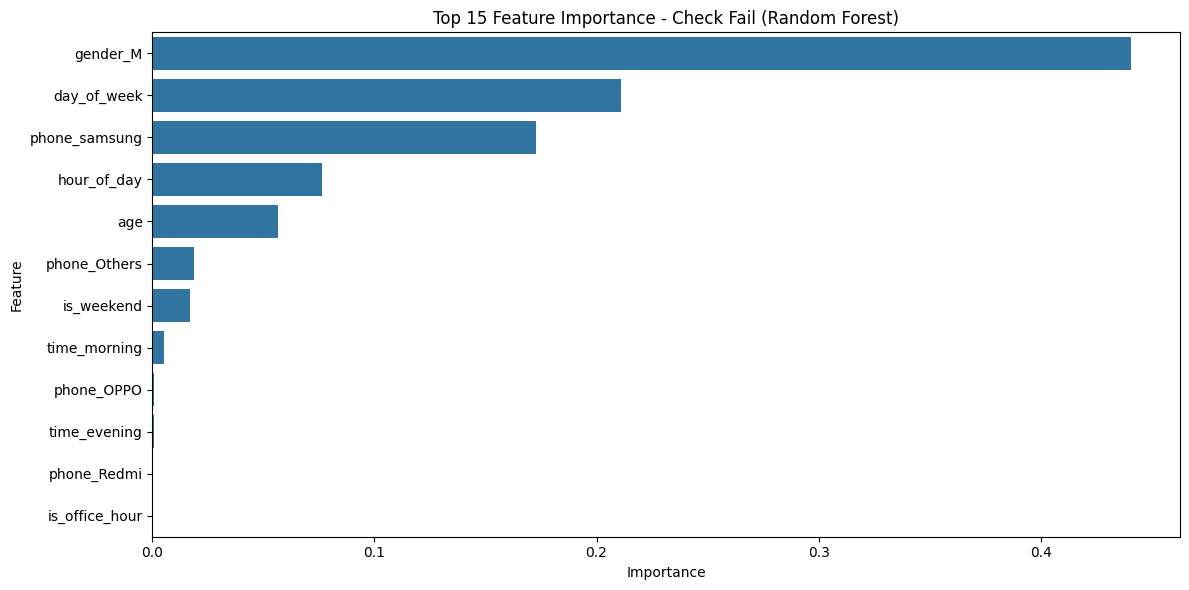


📊 Đánh giá mô hình - Check Fail (Random Forest):
      Metric  Mean Score
0    ROC AUC    0.598490
1   Accuracy    0.585457
2   F1 Score    0.302547
3  Precision    0.207090
4     Recall    0.568967


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV, cross_validate
from sklearn.metrics import classification_report, roc_auc_score, make_scorer, f1_score, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=5)

# 2. SMOTE + RandomForest Pipeline
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', rf)
])

# 3. Hyperparameter space
param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean (ROC AUC): {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['rf']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Check Fail (Random Forest)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Check Fail (Random Forest):")
print(cv_summary)


### XGBoost

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best hyperparameters:
{'xgb__subsample': 0.6, 'xgb__n_estimators': 100, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 0.6}
📈 CV score mean: 0.5939


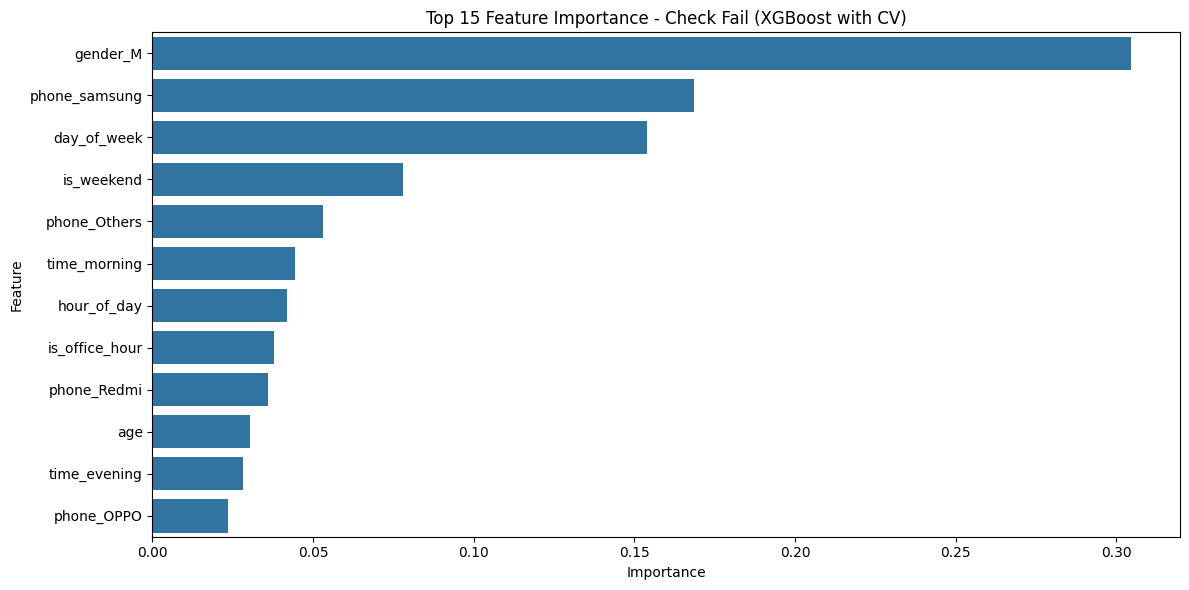


📊 Đánh giá mô hình - Check Fail:
      Metric  Mean Score
0    ROC AUC    0.593940
1   Accuracy    0.665773
2   F1 Score    0.265697
3  Precision    0.204597
4     Recall    0.381822


In [ ]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu
def build_user_level_step_dataset(df, step):
    """
    df: full record-level dataframe (df_model_combine)
    step: stop_point_mapped bạn muốn phân tích (int)
    """
    # 1. Loại các khách chưa từng đi đến bước X
    eligible_customers = df.groupby('customer_id')['stop_point_mapped'].max()
    eligible_customers = eligible_customers[eligible_customers >= step].index
    df_eligible = df[df['customer_id'].isin(eligible_customers)].copy()

    # 2. Tạo target: từng fail ở step X
    # Nếu có bất kỳ record nào stop_point_mapped == step thì là 1
    fail_target = (
        df_eligible.groupby('customer_id')['stop_point_mapped']
        .apply(lambda x: int((x == step).any()))
        .rename(f'fail_step_{step}')
    )

    # 3. Lấy thông tin đặc trưng đầu vào (lấy dòng đầu tiên hoặc phổ biến nhất)
    df_features = df_eligible.groupby('customer_id').first().reset_index()

    # 4. Gộp target vào đặc trưng
    df_user = df_features.merge(fail_target, on='customer_id', how='left')

    # 5. Chuẩn bị X, y
    cols = [ 'age', 'hour_of_day', 'day_of_week', 'is_office_hour', 'is_weekend', 'gender_M', 'phone_OPPO',
       'phone_Others', 'phone_Redmi', 'phone_samsung', 'time_evening', 'time_morning']  # Các cột muốn cho vào mô hình
    X = df_user[cols]
    y = df_user[f'fail_step_{step}']

    return X, y, df_user

X, y, df_user_step = build_user_level_step_dataset(df_model_combine, step=5)

# 2. SMOTE + XGBoost Pipeline
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('xgb', xgb)
])

# 3. Hyperparameter space
param_dist = {
    'xgb__n_estimators': [100, 200, 300],
    'xgb__max_depth': [3, 5, 7],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0]
}

# 4. RandomizedSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    scoring='roc_auc',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

rs.fit(X, y)

# 5. Kết quả tổng hợp
best_model = rs.best_estimator_
best_params = rs.best_params_
cv_score_mean = rs.best_score_

print("✅ Best hyperparameters:")
print(best_params)
print(f"📈 CV score mean: {cv_score_mean:.4f}")

# 6. Final model để phân tích feature importance
final_model = best_model.named_steps['xgb']
final_model.fit(*SMOTE(random_state=42).fit_resample(X, y))

# 7. Feature importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(15))
plt.title("Top 15 Feature Importance - Check Fail (XGBoost with CV)")
plt.tight_layout()
plt.show()

# 8. Cross Validation mở rộng
from sklearn.model_selection import cross_validate
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

scoring = {
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy',
    'f1': make_scorer(f1_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score)
}

cv_results = cross_validate(
    estimator=rs.best_estimator_,
    X=X,
    y=y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    'Metric': ['ROC AUC', 'Accuracy', 'F1 Score', 'Precision', 'Recall'],
    'Mean Score': [
        cv_results['test_roc_auc'].mean(),
        cv_results['test_accuracy'].mean(),
        cv_results['test_f1'].mean(),
        cv_results['test_precision'].mean(),
        cv_results['test_recall'].mean()
    ]
})

print("\n📊 Đánh giá mô hình - Check Fail:")
print(cv_summary)
